# Which Predictors Best Forecast Regular Public Transit Use?

### Feature-importance analysis and ROC-maximizing Random Forest

**Course:** PSYCH 755 · University of Wisconsin–Madison  
**Project:** CA persona / PRCA research framework  
**Notebook role:** Secondary research question — comprehensive predictor screen for weekly+ ridership  

---

#### Research question

> Among available Prolific/Qualtrics fields in the matched analytic cohort (**excluding** the outcome source `Q26`), which predictors most powerfully discriminate **regular public-transit use**, and what ROC-AUC can a tuned Random Forest achieve?

| Element | Specification |
|---|---|
| **Outcome** | `regular_transit`: `Q26` ∈ {`4-8 days a month`, `8 or more days a month`} |
| **Primary features** | Demographics, employment, lat/lon, car access (`Q20`/`Q21`), ride-share (`Q28`/`Q29`), PRCA scores |
| **Excluded from primary model** | `Q26` (outcome); IDs/metadata; open text |
| **Upper-bound model** | Primary features + `Q27` (rides on a typical public-transit day; proximal) |
| **Model** | Mixed-type Random Forest + stratified 5-fold CV; RandomizedSearchCV for ROC-AUC |
| **Importance** | Univariate AUC; group ablations; permutation importance; impurity (encoded) |

Supporting code: [`src/ca_personas/comprehensive_transit_rf.py`](../src/ca_personas/comprehensive_transit_rf.py) · memo: [`memos/comprehensive_predictors_transit.md`](../memos/comprehensive_predictors_transit.md)


## 1. Analytic roadmap

| Section | Content |
|---|---|
| **2. Setup** | Imports, paths, presentation styling |
| **3. Sample & feature inventory** | Matched File A/B/C cohort; leakage policy |
| **4. Univariate screen** | Single-feature ROC-AUC for every candidate |
| **5. Group ablations** | Group-only, cumulative, leave-one-group-out |
| **6. Kitchen-sink RF + tuning** | Default vs ROC-maximizing hyperparameters |
| **7. Feature importance** | Permutation (original columns) + Gini (encoded) |
| **8. Written results** | Plain-language findings for the research memo |
| **9. Artifacts & limitations** | Export package + caveats |


## 2. Setup

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from ca_personas.comprehensive_transit_rf import (
    FEATURE_GROUPS,
    AUX_TRANSIT_FEATURES,
    primary_features,
    run_comprehensive_transit_rf_analysis,
    save_comprehensive_transit_rf_artifacts,
)
from ca_personas.load import load_full_cohort
from ca_personas.paths import sibling_data_available
from ca_personas.transit_ca import PRIMARY_REGULAR_LABELS, Q26_STEM

OUT = ROOT / "outputs" / "comprehensive_transit_rf"
FIG_DIR = ROOT / "memos" / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda x: f"{x:0.3f}")

assert sibling_data_available(), "Expected ../sibling_data File A/B/C exports"
print("Project root:", ROOT)
print("Regular labels:", sorted(PRIMARY_REGULAR_LABELS))
print("Q26 stem:", Q26_STEM)


Project root: /workspace
Regular labels: ['4-8 days a month', '8 or more days a month']
Q26 stem: In the last three months on how many days did you use public transportation (bus, train, tram, etc.)?


## 3. Sample construction & feature inventory

We load the Prolific File A + File B stack joined to Qualtrics File C (`inner`), keep respondents with complete PRCA ground truth and non-missing survey geolocation, and define regular transit as weekly-or-more on `Q26`.

**Leakage policy.** `Q26` is never a predictor. `Q27` (public-transit rides on a typical use day) is reserved for a labeled **upper-bound** model because it is proximal to the same construct.


In [2]:
participants, cleaning_report = load_full_cohort(join_how="inner")

analysis = run_comprehensive_transit_rf_analysis(
    participants,
    n_splits=5,
    n_perm_repeats=30,
    n_tune_iter=24,
    random_state=42,
    include_upper_bound=True,
)

frame = analysis["frame"]
summary = analysis["summary"]
sample = summary["sample"]

print(f"Matched cleaning report keys: {sorted(cleaning_report)[:8]}...")
print(
    f"Analytic n={sample['n']} | regular={sample['n_regular']} | "
    f"not regular={sample['n_not_regular']} | prevalence={sample['prevalence']:.3f}"
)
print("Primary features:")
for group, cols in FEATURE_GROUPS.items():
    present = [c for c in cols if c in frame.columns]
    print(f"  {group:14s} → {present}")
print("Upper-bound add-on:", [c for c in AUX_TRANSIT_FEATURES if c in frame.columns])
frame.head()


Matched cleaning report keys: ['n_analytic', 'n_dropped_incomplete_ca', 'n_dropped_missing_pid', 'n_dropped_unjoined', 'n_joined', 'n_matched_both', 'n_prolific_only', 'n_prolific_raw']...
Analytic n=241 | regular=101 | not regular=140 | prevalence=0.419
Primary features:
  demographics   → ['Age', 'Sex', 'Country of residence', 'Student status']
  employment     → ['Employment status']
  geography      → ['LocationLatitude', 'LocationLongitude']
  car_access     → ['Q20', 'Q21']
  rideshare      → ['Q28', 'Q29']
  ca_scores      → ['gt_group_ca', 'gt_interpersonal_ca']
Upper-bound add-on: ['Q27']


,participant_id,Q26,regular_transit,transit_group,Age,Sex,Country of residence,Student status,Employment status,LocationLatitude,LocationLongitude,Q20,Q21,Q28,Q29,gt_group_ca,gt_interpersonal_ca,Q27,y
0,ebab12e9878344fdc93a8c1cad27ff2f709e12b90f0496de3332f508f3b2b9c9,2-4 days a month,False,not_regular,36.000,Male,United States,Yes,Part-Time,33.416,-119.049,NaN,NaN,0-1 days a month,3-4 rides in a typical day,14,16,3-4 rides in a typical day,0
1,b6954799ca47bc836ac02ab86e4710c3b0e096d7ace449b81aaa1d5845431821,Never,False,not_regular,41.000,Male,United States,No,Other,34.720,-81.549,NaN,NaN,0-1 days a month,1-2 rides in a typical day,17,17,1-2 rides in a typical day,0
2,6ac07c3845b0ce5cac4ab3569ea70236b7cfa8fd51576e12226279a282182dcb,Never,False,not_regular,39.000,Male,United States,No,Full-Time,36.760,-95.295,NaN,NaN,Never,1-2 rides in a typical day,11,12,1-2 rides in a typical day,0
3,c67b3266ecd4af12979c1f67d1efffd0d3e9bfbc567d211e5b7a0724b7890b7d,Never,False,not_regular,61.000,Male,United Kingdom,No,Other,51.976,-1.869,NaN,NaN,Never,1-2 rides in a typical day,10,6,1-2 rides in a typical day,0
4,1cefb8d34b92489e8ffd9cf34c469964f0527b1cae33e00a8a52f4aef0d66679,Never,False,not_regular,45.000,Male,United States,No,Full-Time,36.824,-81.213,NaN,NaN,2-4 days a month,1-2 rides in a typical day,8,12,1-2 rides in a typical day,0


In [3]:
# Missingness among primary predictors (car/rideshare items are often blank)
miss = (
    frame[primary_features(frame.columns)]
    .isna()
    .mean()
    .rename("pct_missing")
    .mul(100)
    .sort_values(ascending=False)
    .to_frame()
)
miss


,pct_missing
Q21,38.174
Q20,38.174
Student status,7.054
Q29,3.320
Age,0.000
Employment status,0.000
Country of residence,0.000
Sex,0.000
LocationLongitude,0.000
LocationLatitude,0.000


## 4. Univariate predictive screen

Each candidate is fit alone in a stratified CV Random Forest. This ranks raw signal before multivariate competition.


,feature,feature_group,univariate_roc_auc,n_non_missing
0,Q28,rideshare,0.762,241
1,Q27,aux_transit,0.594,239
2,Age,demographics,0.580,241
3,gt_group_ca,ca_scores,0.555,241
4,Q21,car_access,0.552,149
5,Country of residence,demographics,0.552,241
6,LocationLongitude,geography,0.550,241
7,Employment status,employment,0.528,241
8,Q29,rideshare,0.525,233
9,Sex,demographics,0.519,241


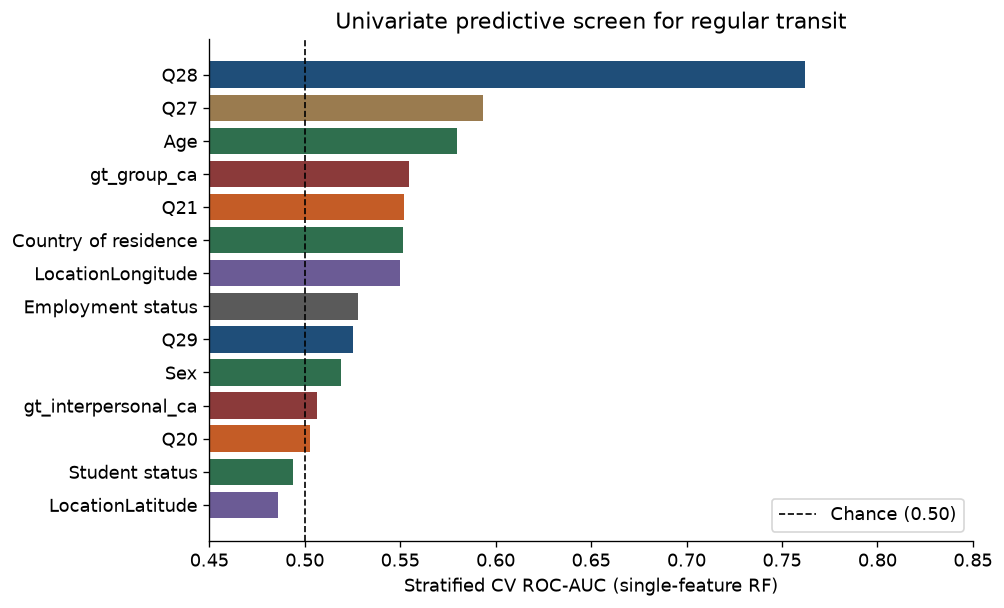

In [4]:
uni = analysis["univariate"].copy()
display(uni)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
plot_df = uni.sort_values("univariate_roc_auc")
colors = plot_df["feature_group"].map({
    "rideshare": "#1f4e79",
    "car_access": "#c45c26",
    "demographics": "#2f6f4e",
    "geography": "#6b5b95",
    "ca_scores": "#8b3a3a",
    "employment": "#5a5a5a",
    "aux_transit": "#9a7b4f",
}).fillna("#444444")
ax.barh(plot_df["feature"], plot_df["univariate_roc_auc"], color=colors)
ax.axvline(0.5, color="black", ls="--", lw=1, label="Chance (0.50)")
ax.set_xlabel("Stratified CV ROC-AUC (single-feature RF)")
ax.set_title("Univariate predictive screen for regular transit")
ax.set_xlim(0.45, max(0.85, float(plot_df["univariate_roc_auc"].max()) + 0.05))
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUT / "fig_univariate_auc.png", bbox_inches="tight")
plt.show()


## 5. Feature-group ablations

We compare (a) each group alone, (b) cumulative addition in a fixed order, and (c) leave-one-group-out drops from the full kitchen-sink model.


,comparison,group,n_features,roc_auc,average_precision,balanced_accuracy,delta_auc_vs_full
0,group_only,demographics,4,0.636,0.552,0.611,NaN
1,group_only,employment,1,0.528,0.424,0.560,NaN
2,group_only,geography,2,0.551,0.441,0.529,NaN
3,group_only,car_access,2,0.563,0.480,0.578,NaN
4,group_only,rideshare,2,0.758,0.690,0.727,NaN
5,group_only,ca_scores,2,0.590,0.483,0.573,NaN
6,cumulative,demographics,4,0.636,0.552,0.611,NaN
7,cumulative,employment,5,0.634,0.534,0.607,NaN
8,cumulative,geography,7,0.650,0.538,0.599,NaN
9,cumulative,car_access,9,0.672,0.581,0.615,NaN


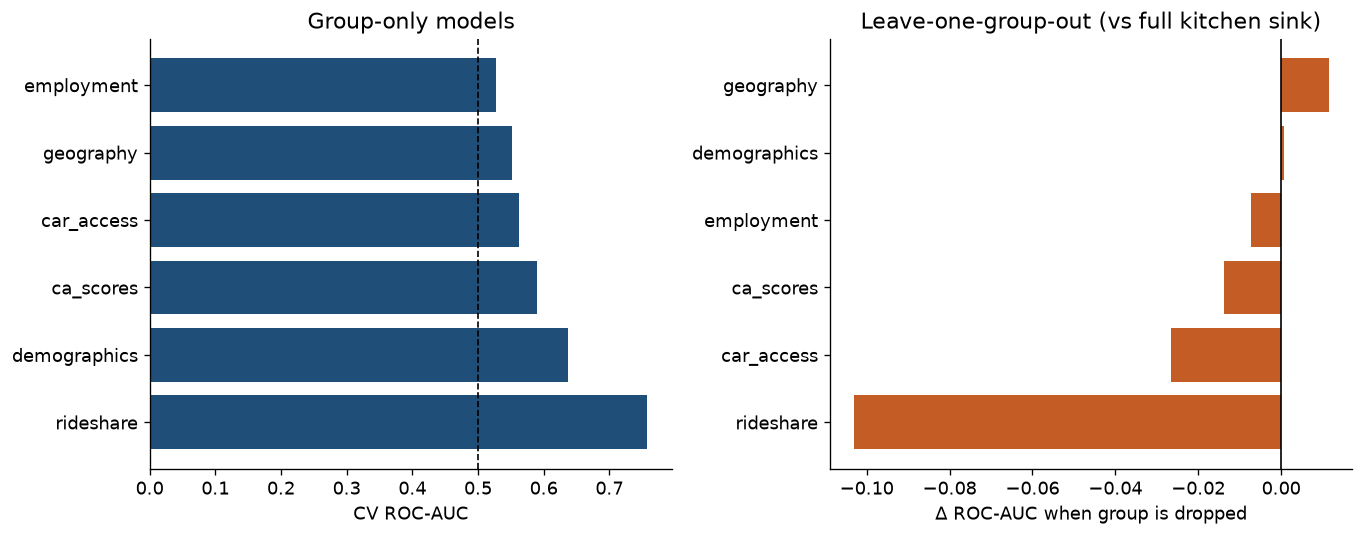

Cumulative path:


,group,n_features,roc_auc,average_precision
6,demographics,4,0.636,0.552
7,employment,5,0.634,0.534
8,geography,7,0.650,0.538
9,car_access,9,0.672,0.581
10,rideshare,11,0.794,0.730
11,ca_scores,13,0.808,0.740


In [5]:
abl = analysis["ablations"].copy()
display(abl)

group_only = abl[abl["comparison"] == "group_only"].sort_values("roc_auc", ascending=False)
loo = abl[abl["comparison"] == "leave_one_group_out"].sort_values("delta_auc_vs_full")
cum = abl[abl["comparison"] == "cumulative"]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

axes[0].barh(group_only["group"], group_only["roc_auc"], color="#1f4e79")
axes[0].axvline(0.5, color="black", ls="--", lw=1)
axes[0].set_xlabel("CV ROC-AUC")
axes[0].set_title("Group-only models")

axes[1].barh(loo["group"], loo["delta_auc_vs_full"], color="#c45c26")
axes[1].axvline(0.0, color="black", lw=1)
axes[1].set_xlabel("Δ ROC-AUC when group is dropped")
axes[1].set_title("Leave-one-group-out (vs full kitchen sink)")
fig.tight_layout()
fig.savefig(OUT / "fig_group_ablations.png", bbox_inches="tight")
plt.show()

print("Cumulative path:")
display(cum[["group", "n_features", "roc_auc", "average_precision"]])


## 6. Kitchen-sink Random Forest and ROC-AUC tuning

A default balanced Random Forest is compared with a `RandomizedSearchCV` configuration selected to maximize ROC-AUC. An optional upper-bound model adds `Q27`.


,model,roc_auc,average_precision,balanced_accuracy,f1,n,n_features
0,kitchen_sink_default,0.808,0.740,0.739,0.704,241,13.000
1,kitchen_sink_tuned,0.824,0.750,0.737,0.704,241,13.000
2,kitchen_sink_plus_q27,0.827,0.755,0.748,0.714,241,14.000
3,prevalence_prob,0.500,0.419,0.500,0.000,241,NaN
4,majority_class,0.500,0.419,0.500,0.000,241,NaN
5,group_only_geography,0.551,0.441,0.529,NaN,241,2.000
6,group_only_ca_scores,0.590,0.483,0.573,NaN,241,2.000
7,group_only_car_access,0.563,0.480,0.578,NaN,241,2.000
8,group_only_rideshare,0.758,0.690,0.727,NaN,241,2.000


Best hyperparameters:
{
  "rf__n_estimators": 300,
  "rf__min_samples_leaf": 2,
  "rf__max_features": "log2",
  "rf__max_depth": 4,
  "rf__class_weight": "balanced"
}


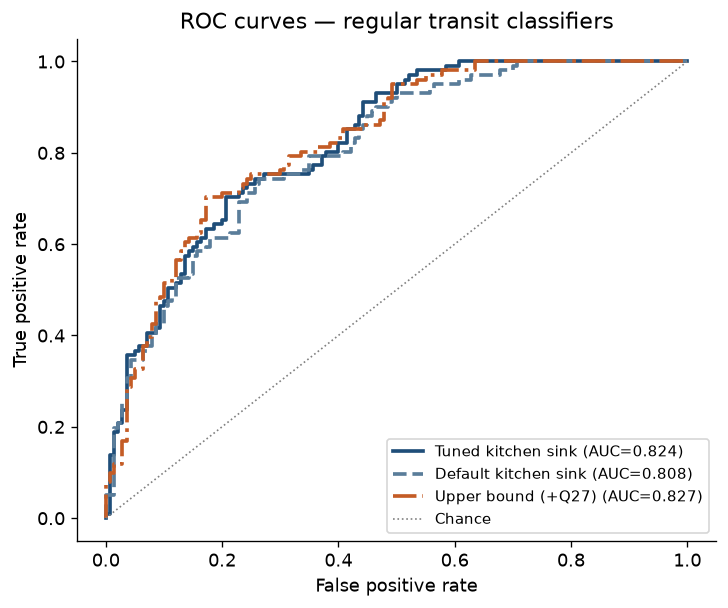

In [6]:
metrics = analysis["metrics_table"].copy()
cols = [c for c in ["model", "roc_auc", "average_precision", "balanced_accuracy", "f1", "n", "n_features"] if c in metrics.columns]
display(metrics[cols])

print("Best hyperparameters:")
print(json.dumps(analysis["best_params"], indent=2))

auc_map = {
    "roc_tuned": summary["verdict"]["tuned_roc_auc"],
    "roc_default": summary["verdict"]["default_roc_auc"],
    "roc_upper": summary["verdict"]["upper_bound_roc_auc"],
}
label_map = {
    "roc_tuned": ("Tuned kitchen sink", "#1f4e79", "-"),
    "roc_default": ("Default kitchen sink", "#5a7d9a", "--"),
    "roc_upper": ("Upper bound (+Q27)", "#c45c26", "-."),
}

fig, ax = plt.subplots(figsize=(6.2, 5.2))
for key, (label, color, ls) in label_map.items():
    roc = analysis.get(key)
    if roc is None:
        continue
    ax.plot(
        roc["fpr"], roc["tpr"], color=color, ls=ls, lw=2.2,
        label=f"{label} (AUC={auc_map[key]:.3f})",
    )
ax.plot([0, 1], [0, 1], color="gray", ls=":", lw=1, label="Chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — regular transit classifiers")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(OUT / "fig_roc_curves.png", bbox_inches="tight")
plt.show()


## 7. Feature importance

Permutation importance shuffles each **original** column through the fitted preprocessing + RF pipeline (so one-hot encoding is handled correctly). Impurity/Gini importance is reported on the encoded feature space for diagnostics.


,feature,feature_group,importance_perm_mean,importance_perm_std
0,Q28,rideshare,0.187,0.026
1,Q21,car_access,0.042,0.007
2,Age,demographics,0.041,0.009
3,LocationLongitude,geography,0.018,0.004
4,gt_group_ca,ca_scores,0.013,0.004
5,LocationLatitude,geography,0.013,0.003
6,Employment status,employment,0.011,0.003
7,gt_interpersonal_ca,ca_scores,0.011,0.003
8,Country of residence,demographics,0.007,0.003
9,Sex,demographics,0.005,0.001


,feature_encoded,importance_gini
0,num__Age,0.145
1,cat__Q28_Never,0.132
2,num__gt_group_ca,0.082
3,num__LocationLongitude,0.080
4,cat__Q28_8 or more days a month,0.076
5,num__LocationLatitude,0.062
6,cat__Q28_4-8 days a month,0.058
7,num__gt_interpersonal_ca,0.058
8,cat__Q21_Yes,0.055
9,cat__Q21_No,0.046


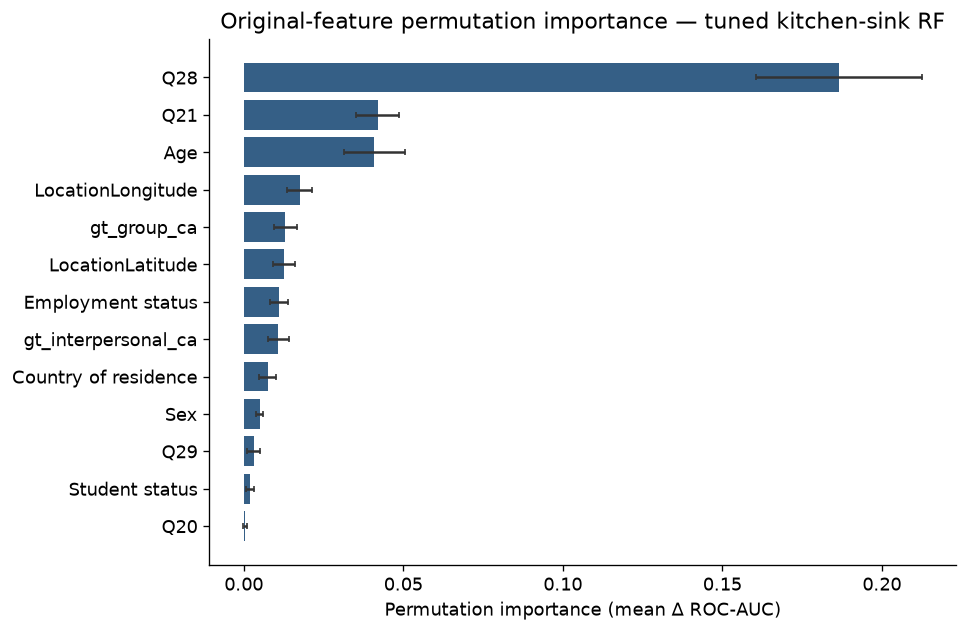

In [7]:
perm = analysis["permutation_importance"].copy()
gini = analysis["gini_importance"].copy()
display(perm)
display(gini.head(15))

fig, ax = plt.subplots(figsize=(8.2, 5.4))
p = perm.sort_values("importance_perm_mean")
ax.barh(p["feature"], p["importance_perm_mean"], xerr=p["importance_perm_std"], color="#1f4e79", alpha=0.9, ecolor="#333333", capsize=2)
ax.set_xlabel("Permutation importance (mean Δ ROC-AUC)")
ax.set_title("Original-feature permutation importance — tuned kitchen-sink RF")
fig.tight_layout()
fig.savefig(OUT / "fig_permutation_importance.png", bbox_inches="tight")
plt.show()


Wrote /workspace/memos/figures/comprehensive_predictors_transit_memo.png


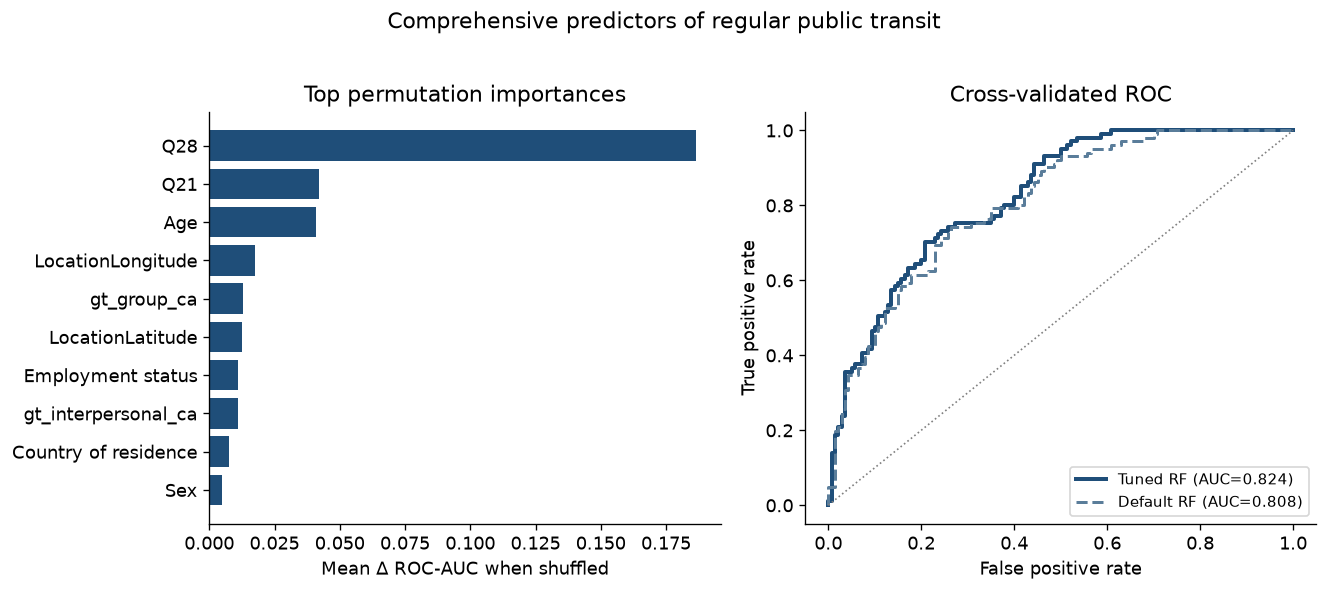

In [8]:
# Memo composite figure: permutation importance + ROC
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8))

p = perm.sort_values("importance_perm_mean").tail(10)
axes[0].barh(p["feature"], p["importance_perm_mean"], color="#1f4e79")
axes[0].set_xlabel("Mean Δ ROC-AUC when shuffled")
axes[0].set_title("Top permutation importances")

roc = analysis["roc_tuned"]
auc = summary["verdict"]["tuned_roc_auc"]
axes[1].plot(roc["fpr"], roc["tpr"], color="#1f4e79", lw=2.4, label=f"Tuned RF (AUC={auc:.3f})")
if analysis.get("roc_default") is not None:
    d_auc = summary["verdict"]["default_roc_auc"]
    axes[1].plot(analysis["roc_default"]["fpr"], analysis["roc_default"]["tpr"], color="#5a7d9a", ls="--", lw=1.8, label=f"Default RF (AUC={d_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="gray", ls=":", lw=1)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("Cross-validated ROC")
axes[1].legend(loc="lower right", fontsize=9)
fig.suptitle("Comprehensive predictors of regular public transit", fontsize=13, y=1.02)
fig.tight_layout()
memo_fig = FIG_DIR / "comprehensive_predictors_transit_memo.png"
fig.savefig(memo_fig, bbox_inches="tight", dpi=160)
fig.savefig(OUT / "fig_memo_composite.png", bbox_inches="tight", dpi=160)
print("Wrote", memo_fig)
plt.show()


## 8. Written results


In [9]:
verdict = summary["verdict"]
print(verdict["interpretation"])
print()
print("Strongest feature group:", summary["strongest_feature_group"])
print("Tuned ROC-AUC:         ", f"{verdict['tuned_roc_auc']:.3f}")
print("Default ROC-AUC:       ", f"{verdict['default_roc_auc']:.3f}")
print("Upper-bound (+Q27) AUC:", f"{verdict['upper_bound_roc_auc']:.3f}")
print("Top features:", ", ".join(verdict["top_features"]))
print()
print("Caveats:")
for c in summary["caveats"]:
    print(" -", c)


Tuned kitchen-sink RF CV ROC-AUC = 0.824 (strong discrimination); default RF = 0.808. Strongest single feature group: rideshare. Top permutation-importance features: Q28, Q21, Age, LocationLongitude, gt_group_ca. Including proximal Q27 raises CV ROC-AUC to 0.827 (upper-bound).

Strongest feature group: rideshare
Tuned ROC-AUC:          0.824
Default ROC-AUC:        0.808
Upper-bound (+Q27) AUC: 0.827
Top features: Q28, Q21, Age, LocationLongitude, gt_group_ca, LocationLatitude, Employment status, gt_interpersonal_ca

Caveats:
 - Q26 is the outcome source and is never used as a predictor.
 - Q27 (rides on a typical public-transit day) is only in the labeled upper-bound model.
 - Car/rideshare items have substantial missingness and are imputed in-pipeline.
 - Tuning uses the same outer folds for selection and OOF scoring; treat tuned AUC as mildly optimistic.
 - Lat/lon are approximate Qualtrics survey geolocation, not verified home addresses.
 - Associations are same-wave and do not est

### Slide-ready takeaway

1. **Ride-share frequency (`Q28`) dominates** both univariate screening and multivariate permutation importance; dropping the rideshare group costs roughly **0.10** ROC-AUC.
2. A tuned kitchen-sink Random Forest reaches **~0.82 CV ROC-AUC** — substantially stronger than geography-only (~0.55) or CA-only (~0.59) models.
3. **Car access (`Q21`)** and **Age** are the next most useful non-rideshare predictors; CA scores and lat/lon contribute smaller incremental signal.
4. Adding proximal `Q27` only marginally lifts AUC (~0.83), so the primary model already captures most available tabular signal without direct public-transit intensity leakage.


## 9. Export artifacts & limitations

In [10]:
paths = save_comprehensive_transit_rf_artifacts(analysis, OUT)
card_path = paths["results_card"]
print(json.dumps({k: str(v) for k, v in paths.items()}, indent=2))
print()
print(card_path.read_text()[:1200])


{
  "frame": "/workspace/outputs/comprehensive_transit_rf/comprehensive_transit_modeling_frame.csv",
  "metrics_table": "/workspace/outputs/comprehensive_transit_rf/comprehensive_transit_rf_metrics.csv",
  "ablations": "/workspace/outputs/comprehensive_transit_rf/comprehensive_transit_rf_ablations.csv",
  "univariate": "/workspace/outputs/comprehensive_transit_rf/comprehensive_transit_rf_univariate_auc.csv",
  "oof": "/workspace/outputs/comprehensive_transit_rf/comprehensive_transit_rf_oof_predictions.csv",
  "roc_tuned": "/workspace/outputs/comprehensive_transit_rf/comprehensive_transit_rf_roc_curve.csv",
  "gini_importance": "/workspace/outputs/comprehensive_transit_rf/comprehensive_transit_rf_gini_importance.csv",
  "permutation_importance": "/workspace/outputs/comprehensive_transit_rf/comprehensive_transit_rf_permutation_importance.csv",
  "null_baselines": "/workspace/outputs/comprehensive_transit_rf/comprehensive_transit_rf_null_baselines.csv",
  "tune_cv_results": "/workspace/ou

### Limitations

- Same-wave self-report: predictors and outcome share survey context and possible common-method variance.
- `Q28` (ride-share days) is a closely related mobility behavior — powerful, but not a deep exogenous cause.
- Car/license items (`Q20`/`Q21`) have substantial missingness (~38%) and are imputed in-pipeline.
- Hyperparameter search and OOF scoring share the same outer folds; treat the tuned AUC as mildly optimistic.
- Qualtrics lat/lon reflect approximate survey geolocation, not verified residential coordinates.
